# 11. Concentration response

[5. Hits and effects](05_hits_and_effects.ipynb) asked whether a treatment moved. This page asks how much of it
was needed, which is a different design and a different set of traps:

- Most compounds never plateau inside the tested range, so a four-parameter logistic has no EC50 to find.
- Distance from the controls rises when a compound kills cells, which is not the same finding as a phenotype.
- A dose series usually spends its wells on concentrations rather than replicates, so any single concentration is
  thinly measured and the evidence lives in the shape across them.

The dataset is [the OASIS pilot](../datasets/oasis_pilot.ipynb): 36 compounds over ten concentrations, in two
cell lines.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

import mantispy as mt

adata = mt.ds.oasis_pilot()
# EMPTY wells hold no compound and no vehicle, so they are neither treatment nor control.
adata = adata[adata.obs["Metadata_Compound"].astype(str) != "EMPTY"].copy()
heparg = adata[adata.obs["Metadata_CellLine"] == "HepaRG"].copy()
heparg

/Users/tim.treis/Library/Application Support/hatch/env/virtual/mantispy/n7Ku6oea/tutorials/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AnnData object with n_obs × n_vars = 2831 × 99
    obs: 'Metadata_plate_map_name', 'Metadata_Plate', 'Metadata_Well', 'Metadata_Site_Count', 'Metadata_Count_Cells', 'Metadata_Count_CellsIncludingEdges', 'Metadata_Count_Cytoplasm', 'Metadata_Count_Nuclei', 'Metadata_Count_NucleiIncludingEdges', 'Metadata_Object_Count', 'Metadata_CellCount', 'Metadata_SiteCount', 'Metadata_Compound', 'Metadata_Concentration', 'Metadata_CellLine', 'Metadata_Control', 'Metadata_Perturbation'
    var: 'object', 'feature_group', 'feature', 'channel', 'scale', 'angle', 'gray_levels', 'radial_bin', 'params', 'is_feature'
    uns: 'mantispy'
    layers: None (.X)

## The usual preparation

Nothing here is specific to dose response: normalize each plate against its own controls, drop the features with
no spread among those controls, then select features.

In [2]:
mt.pp.normalize(heparg, by="Metadata_Plate", reference="negcon")
heparg = heparg[:, ~heparg.var["degenerate_scale"].to_numpy(dtype=bool)].copy()
mt.pp.feature_select(heparg, na_cutoff=0.0)
heparg = mt.pp.subset_features(heparg)
print(f"{heparg.n_obs} wells, {heparg.n_vars} features kept")

2831 wells, 99 features kept


## A mantispy object is an AnnData object

Nothing stops scanpy from working on it, which is the point of the format. The PCA, the neighbour graph and the
UMAP come from scanpy; the colours come from the columns `mt.ds.oasis_pilot` attached.

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_99356/992733786.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


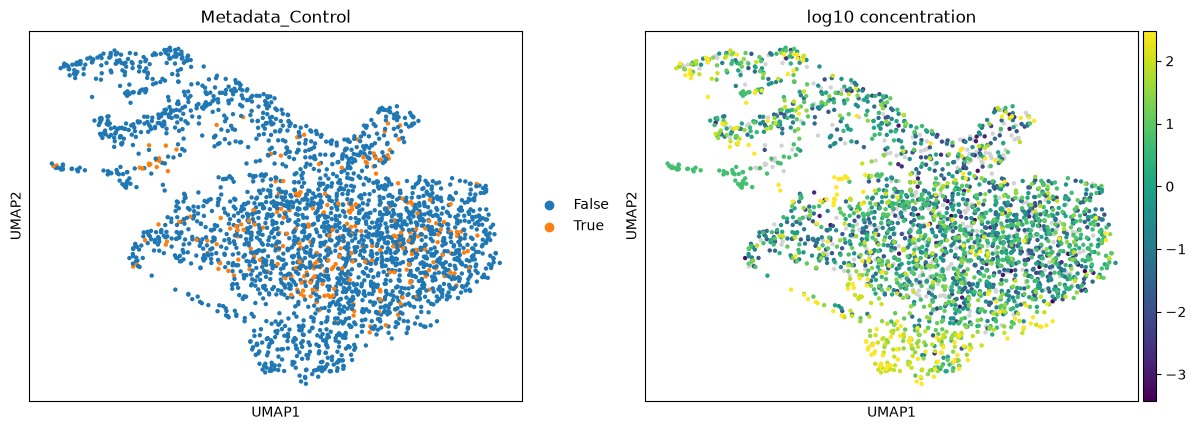

In [3]:
sc.pp.pca(heparg, n_comps=20)
sc.pp.neighbors(heparg)
sc.tl.umap(heparg)

heparg.obs["log10 concentration"] = np.log10(heparg.obs["Metadata_Concentration"].replace(0, np.nan))
sc.pl.umap(heparg, color=["Metadata_Control", "log10 concentration"], size=40, ncols=2, show=False)
plt.tight_layout()

The controls sit together and the highest concentrations sit furthest from them, which is what a dose series
should look like before any statistics are run.

## From profiles to a response per well

{func}`~mantispy.tl.hit_calling` writes two columns. `hits_distance` is the group's statistic repeated over its
rows; `hits_row_distance` is each well's own distance from the control centroid. The curve fit needs the second,
because a column that is constant within a group carries no dose information at all.

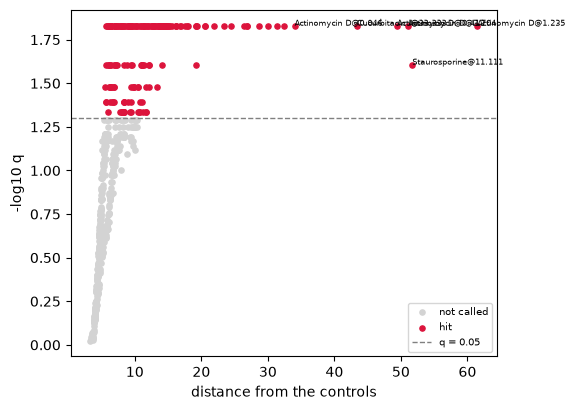

In [4]:
mt.tl.hit_calling(heparg, groupby="Metadata_Perturbation", use_rep="X_pca", n_permutations=300)
ax = mt.pl.hits(heparg, label_top=6)
plt.show()

That warning is worth reading rather than dismissing. Nearly every compound-at-a-concentration here sits in one
or two wells, so the per-group hit call is thin. This is the trade the plate map made: concentrations instead of
replicates. It is also why the next step is a curve rather than a table of per-concentration tests — a fit reads
all ten concentrations together, and the shape across them is what carries the evidence.

## Fitting the concentration response

In [5]:
mt.tl.dose_response(heparg, compound_key="Metadata_Compound", dose_key="Metadata_Concentration", min_doses=4)
curves = heparg.uns["mantispy"]["dose_response"].set_index("compound")
curves = curves[curves.index.astype(str) != "DMSO"]
curves.sort_values("hitcall", ascending=False).head(8)[
    ["n_doses", "spearman", "qvalue", "ec50", "r_squared", "fit_ok", "hitcall", "hitcall_model"]
]

,n_doses,spearman,qvalue,ec50,r_squared,fit_ok,hitcall,hitcall_model
compound,,,,,,,,
Staurosporine,18,0.601492,3.386089e-08,0.240157,0.131893,False,1.0,linear
CLIOQUINOL,19,0.612883,2.123258e-08,75.606859,0.544927,False,1.0,logistic
Amperozide,18,0.520615,2.075043e-06,45.530173,0.530019,False,1.0,logistic
Calcipotriol (hydrate),18,0.560595,2.976855e-07,9.933690,0.386427,False,1.0,logistic
Cucurbitacin I,18,0.521179,2.075043e-06,35.250061,0.171161,False,1.0,linear
Fluazinam,18,0.574980,1.703180e-07,19.725783,0.378008,False,1.0,logistic
"5,6-benzoflavone",18,0.521155,2.075043e-06,39.100805,0.614838,False,1.0,logistic
Colistin Methanesulfonate (sodium salt),18,0.437740,8.568403e-05,6930.981470,0.434041,False,1.0,logistic


Three columns answer three different questions, and they disagree on purpose.

`spearman` with its `qvalue` asks whether the response rises with dose at all. It assumes no shape and works with
three points.

`fit_ok` asks whether the logistic converged on something curve-shaped with an EC50 inside the tested range. On
this screen it is `False` for most compounds, and that is honest: a compound still climbing at the top
concentration has no EC50 in range, so no potency should be quoted for it.

`hitcall` asks the screener's question, whether the response is large next to the noise the controls carry. It is
the product of three confidences from the ToxCast pipeline: that the curve beats a flat fit, that some
concentration's median clears the cutoff, and that the fitted top clears it. The cutoff is three times the
controls' MAD unless you pass one. `hitcall_model` names the shape that won: `logistic` where the curve
plateaus, `linear` where it is still climbing.

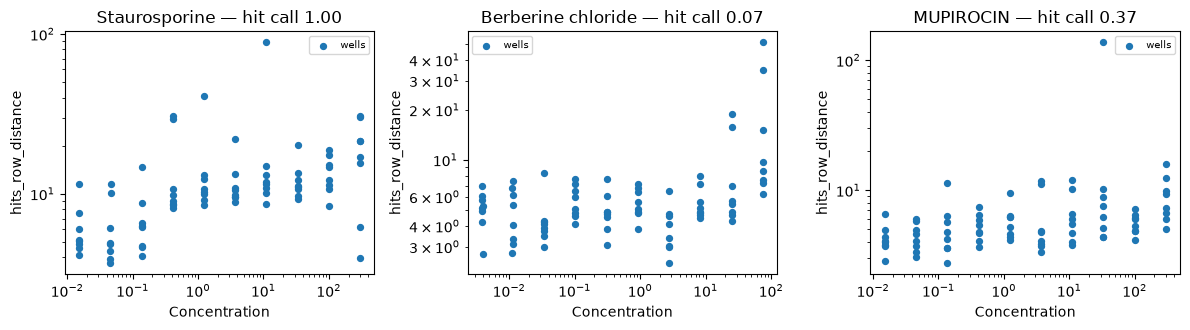

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, compound in zip(axes, ["Staurosporine", "Berberine chloride", "MUPIROCIN"], strict=False):
    mt.pl.dose_response(heparg, compound=compound, ax=ax)
    ax.set_title(f"{compound} — hit call {curves['hitcall'].get(compound, float('nan')):.2f}")
fig.tight_layout()

Staurosporine inhibits kinases broadly and climbs far past the band. Mupirocin inhibits a bacterial enzyme and
has no target in a human cell, so it never leaves it. Berberine barely leaves it either in this cell line, and
the last section says why that is worth checking rather than resolving here.

## Distance is not the same as phenotype

A compound that kills cells also moves away from the controls, and the curve cannot tell the two apart.
{func}`~mantispy.tl.cytotoxicity` compares each group's cells per field against the controls', so the calls can
be read beside it.

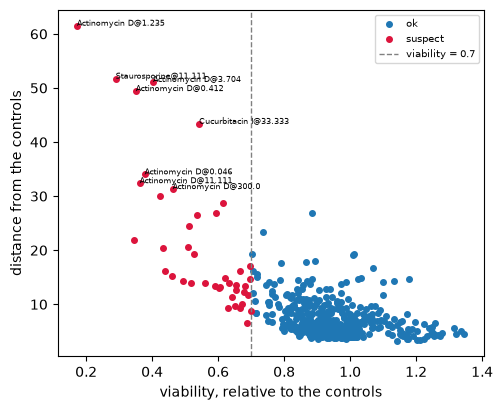

In [7]:
mt.tl.cytotoxicity(heparg, groupby="Metadata_Perturbation")
ax = mt.pl.cytotoxicity(heparg)
plt.show()

A high call with viability near one is a change in the shape of living cells. A high call with viability
collapsed is the morphology of dying cells, which most mechanisms share. The US EPA's phenotypic profiling
pipeline drops any concentration that loses more than half the cells before it fits anything, and that is a
reasonable habit here.

## Does the call survive a second cell line?

The same compounds were dosed in U2OS. The two lines were normalized and feature-selected apart, so their
distances are not on one scale, but their calls can still be compared.

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_99356/2041206685.py:7: UserWarning: 280 of 289 groups have fewer than three rows, so their statistic is the median of one or two wells. Aggregate more replicates, or score activity with mt.tl.map(mode='activity'), which ranks replicate pairs and is built for screens with little replication.
  mt.tl.hit_calling(u2os, groupby="Metadata_Perturbation", use_rep="X_pca", n_permutations=300)


28 shared compounds, 61% called the same way in both


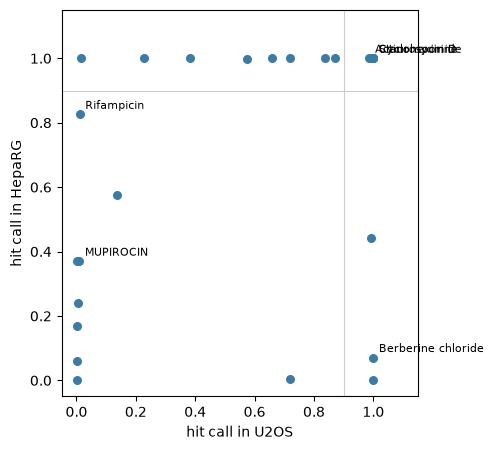

In [8]:
u2os = adata[adata.obs["Metadata_CellLine"] == "U2OS"].copy()
mt.pp.normalize(u2os, by="Metadata_Plate", reference="negcon")
u2os = u2os[:, ~u2os.var["degenerate_scale"].to_numpy(dtype=bool)].copy()
mt.pp.feature_select(u2os, na_cutoff=0.0)
u2os = mt.pp.subset_features(u2os)
sc.pp.pca(u2os, n_comps=20)
mt.tl.hit_calling(u2os, groupby="Metadata_Perturbation", use_rep="X_pca", n_permutations=300)
mt.tl.dose_response(u2os, compound_key="Metadata_Compound", dose_key="Metadata_Concentration", min_doses=4)

other = u2os.uns["mantispy"]["dose_response"].set_index("compound")
both = pd.DataFrame({"U2OS": other["hitcall"], "HepaRG": curves["hitcall"]}).dropna()

fig, ax = plt.subplots(figsize=(5, 4.6))
ax.scatter(both["U2OS"], both["HepaRG"], s=30, color="#3a7ca5", zorder=3)
for compound in ["Staurosporine", "Actinomycin D", "Cycloheximide", "MUPIROCIN", "Rifampicin", "Berberine chloride"]:
    if compound in both.index:
        ax.annotate(
            compound,
            (both.loc[compound, "U2OS"], both.loc[compound, "HepaRG"]),
            fontsize=8,
            xytext=(4, 4),
            textcoords="offset points",
        )
ax.axvline(0.9, color="0.8", lw=0.8, zorder=0)
ax.axhline(0.9, color="0.8", lw=0.8, zorder=0)
ax.set(xlabel="hit call in U2OS", ylabel="hit call in HepaRG", xlim=(-0.05, 1.15), ylim=(-0.05, 1.15))
print(
    f"{len(both)} shared compounds, "
    f"{((both['U2OS'] >= 0.9) == (both['HepaRG'] >= 0.9)).mean():.0%} called the same way in both"
)
fig.tight_layout()

The corners carry the biology. Staurosporine, actinomycin D and cycloheximide inhibit kinases, transcription and
translation, and are called in both lines. Mupirocin and rifampicin are antibacterials with no mammalian target,
and are called in neither. Berberine sits off the diagonal, called in U2OS and not in HepaRG, which is a
statement about two cell types rather than a failure of the fit.

## Summary

- Use `hits_row_distance` as the response, not `hits_distance`. The group column is one number repeated over its
  wells.
- `fit_ok` and `hitcall` answer different questions. Quote an EC50 only when `fit_ok` is `True`; use `hitcall` to
  decide whether anything happened at all.
- The cutoff comes from the controls, so a screen with few or drifting controls gives a hit call you should not
  trust. {func}`~mantispy.pp.well_qc` and
  [8. Trustworthy features and design](08_trustworthy_features_and_design.ipynb) come first.
- Read every call beside a cell count.
- A call that holds in a second cell line is worth more than a small q-value in one.